In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("traffic_cleaned.csv")

df['date'] = pd.to_datetime(df['date'])

print("Dataset loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))



Dataset loaded successfully!
Rows: 122567
Columns: 9


In [2]:
total_events = len(df)

print("Total Events:", total_events)

Total Events: 122567


In [3]:
event_counts = df['event'].value_counts()

print(event_counts)

event
pageview    73360
click       32499
preview     16708
Name: count, dtype: int64


In [4]:
event_percentage = (
    df['event'].value_counts(normalize=True) * 100
).round(2)

print(event_percentage)

event
pageview    59.85
click       26.52
preview     13.63
Name: proportion, dtype: float64


In [5]:
event_summary = pd.DataFrame({
    'Event': event_counts.index,
    'Count': event_counts.values,
    'Percentage': event_percentage.values
})

event_summary

,Event,Count,Percentage
0,pageview,73360,59.85
1,click,32499,26.52
2,preview,16708,13.63


In [6]:
pageviews = event_counts.get('pageview', 0)
clicks = event_counts.get('click', 0)

pageview_to_click_rate = (clicks / pageviews) * 100

print("Pageview-to-Click Rate:",
      round(pageview_to_click_rate, 2), "%")

Pageview-to-Click Rate: 44.3 %


In [7]:
previews = event_counts.get('preview', 0)

preview_rate = (previews / pageviews) * 100

print("Preview-to-Pageview Event Rate:",
      round(preview_rate, 2), "%")

Preview-to-Pageview Event Rate: 22.78 %


In [8]:
previews = event_counts.get('preview', 0)

preview_rate = (previews / pageviews) * 100

print("Preview-to-Pageview Event Rate:",
      round(preview_rate, 2), "%")

Preview-to-Pageview Event Rate: 22.78 %


In [3]:
daily_traffic = df.groupby('date').size()

print(daily_traffic)

date
2021-08-19    21156
2021-08-20    18536
2021-08-21    16701
2021-08-22    16927
2021-08-23    16415
2021-08-24    16291
2021-08-25    16541
dtype: int64


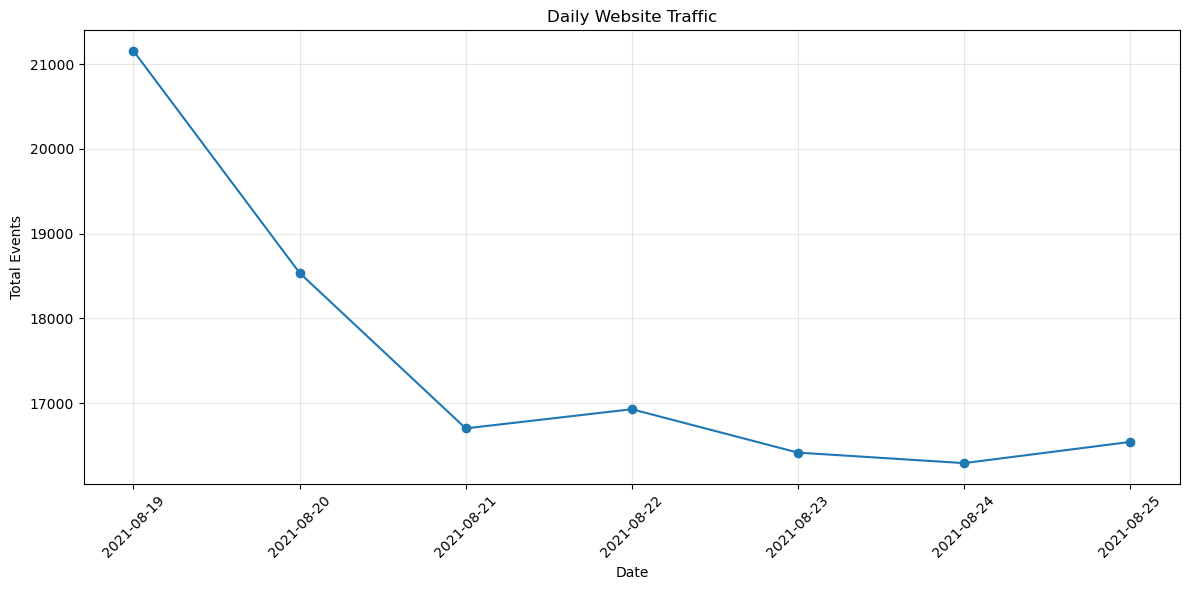

In [4]:
plt.figure(figsize=(12, 6))

plt.plot(
    daily_traffic.index,
    daily_traffic.values,
    marker='o'
)

plt.title('Daily Website Traffic')
plt.xlabel('Date')
plt.ylabel('Total Events')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
daily_event = (
    df.groupby(['date', 'event'])
      .size()
      .unstack(fill_value=0)
)

daily_event

event,click,pageview,preview
date,,,
2021-08-19,5860,13006,2290
2021-08-20,4999,11088,2449
2021-08-21,4279,9939,2483
2021-08-22,4421,9982,2524
2021-08-23,4314,9722,2379
2021-08-24,4231,9705,2355
2021-08-25,4395,9918,2228


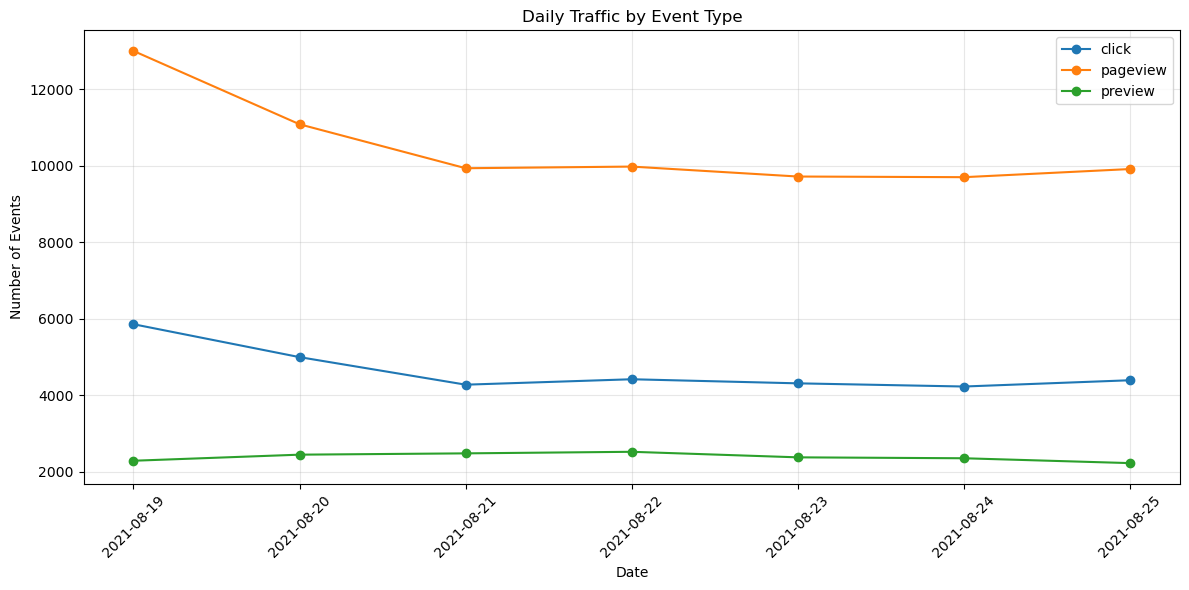

In [17]:
plt.figure(figsize=(12, 6))

for column in daily_event.columns:
    plt.plot(
        daily_event.index,
        daily_event[column],
        marker='o',
        label=column
    )

plt.title('Daily Traffic by Event Type')
plt.xlabel('Date')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)
plt.legend()

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
daily_event = (
    df.groupby(['date', 'event'])
      .size()
      .unstack(fill_value=0)
)

daily_event

event,click,pageview,preview
date,,,
2021-08-19,5860,13006,2290
2021-08-20,4999,11088,2449
2021-08-21,4279,9939,2483
2021-08-22,4421,9982,2524
2021-08-23,4314,9722,2379
2021-08-24,4231,9705,2355
2021-08-25,4395,9918,2228


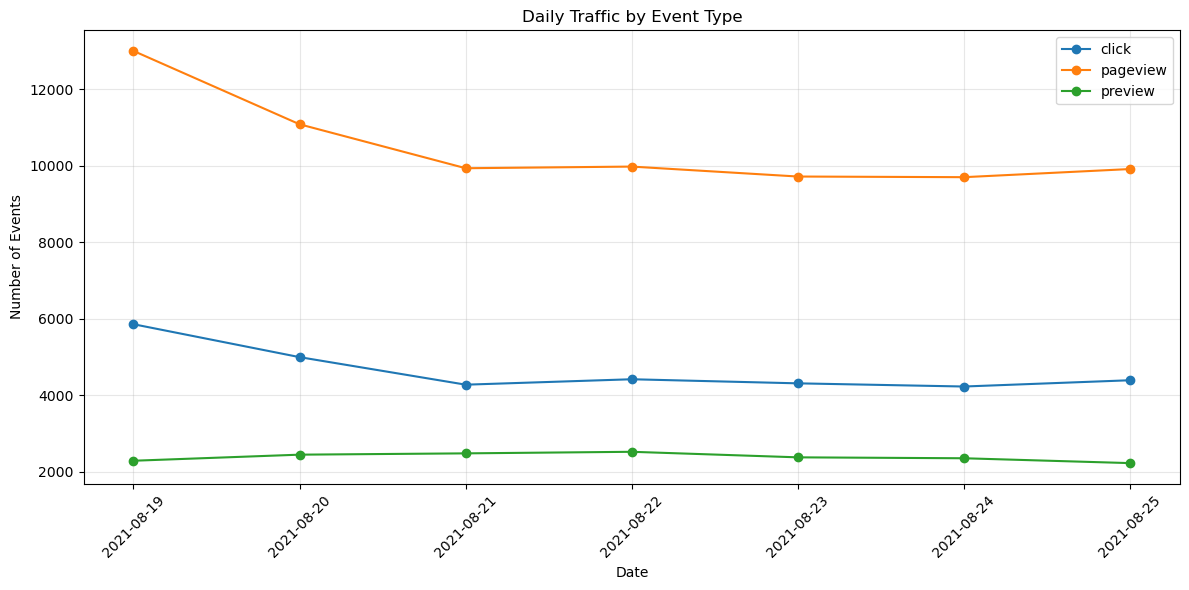

In [8]:
plt.figure(figsize=(12,6))

for column in daily_event.columns:
    plt.plot(
        daily_event.index,
        daily_event[column],
        marker='o',
        label=column
    )

plt.title('Daily Traffic by Event Type')
plt.xlabel('Date')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)
plt.legend()

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
daily_rates = daily_event.div(
    daily_event.sum(axis=1),
    axis=0
) * 100

daily_rates.round(2)

event,click,pageview,preview
date,,,
2021-08-19,27.70,61.48,10.82
2021-08-20,26.97,59.82,13.21
2021-08-21,25.62,59.51,14.87
2021-08-22,26.12,58.97,14.91
2021-08-23,26.28,59.23,14.49
2021-08-24,25.97,59.57,14.46
2021-08-25,26.57,59.96,13.47


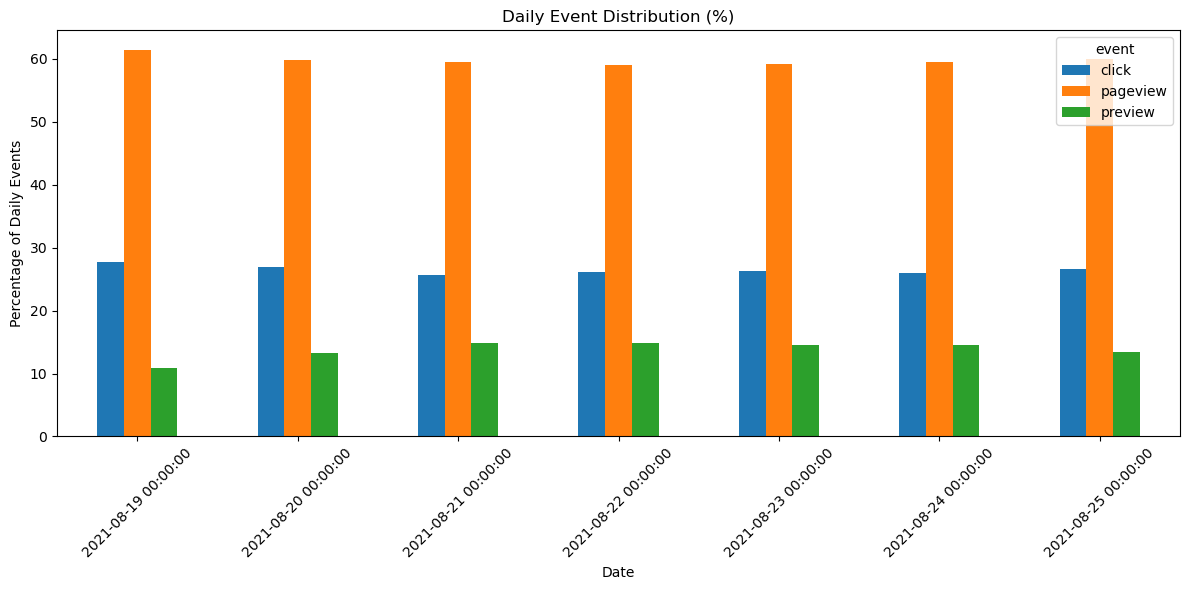

In [12]:
daily_rates.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Daily Event Distribution (%)')
plt.xlabel('Date')
plt.ylabel('Percentage of Daily Events')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [13]:
country_traffic = (
    df.groupby('country')
      .size()
      .sort_values(ascending=False)
)

country_traffic.head(10)

country
United States     28664
India             18689
France            10565
Saudi Arabia       7682
United Kingdom     5095
Germany            4017
Canada             2784
Pakistan           2633
Iraq               2444
Turkey             2399
dtype: int64

In [14]:
top_10_countries = country_traffic.head(10)

top_10_countries

country
United States     28664
India             18689
France            10565
Saudi Arabia       7682
United Kingdom     5095
Germany            4017
Canada             2784
Pakistan           2633
Iraq               2444
Turkey             2399
dtype: int64

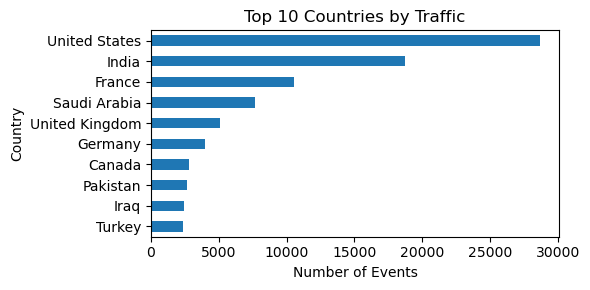

In [16]:
plt.figure(figsize=(6, 3))

top_10_countries.sort_values().plot(kind='barh')

plt.title('Top 10 Countries by Traffic')
plt.xlabel('Number of Events')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

In [17]:
country_event = pd.crosstab(
    df['country'],
    df['event']
)

country_event.head()

event,click,pageview,preview
country,,,
Afghanistan,0,2,0
Albania,58,231,58
Algeria,96,328,91
American Samoa,1,3,0
Andorra,0,2,1


In [18]:
top_countries = country_traffic.head(10).index

country_event_top10 = country_event.loc[top_countries]

country_event_top10

event,click,pageview,preview
country,,,
United States,8446,18131,2087
India,5360,10565,2764
France,2792,6181,1592
Saudi Arabia,1976,3712,1994
United Kingdom,1307,3218,570
Germany,1030,2585,402
Canada,840,1702,242
Pakistan,754,1382,497
Iraq,567,1285,592


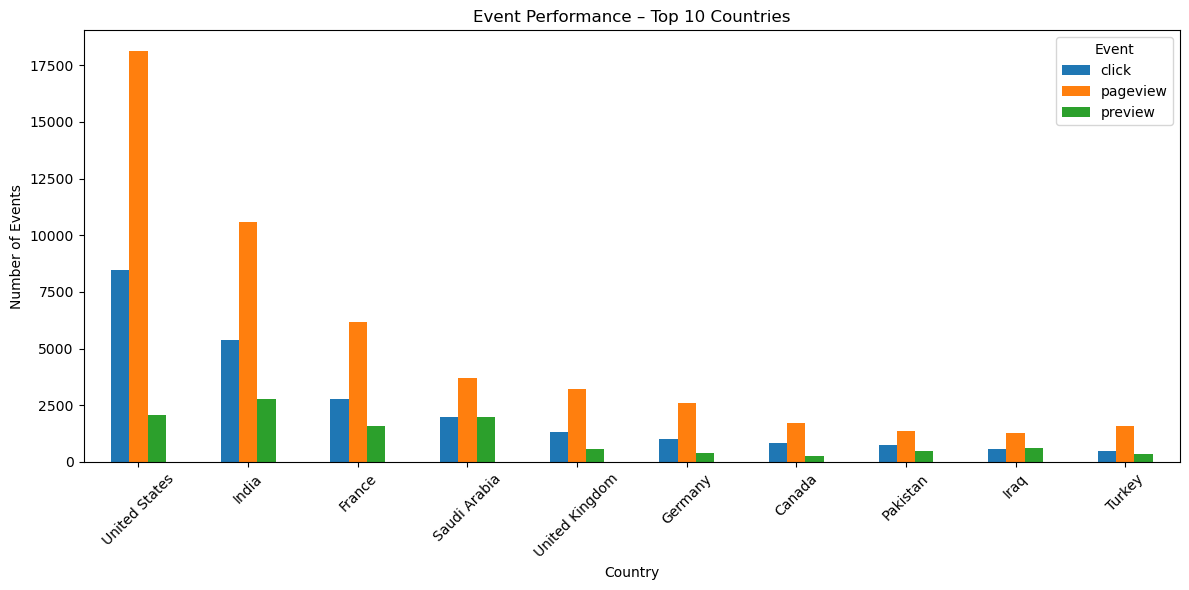

In [21]:
country_event_top10.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Event Performance – Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)
plt.legend(title='Event')

plt.tight_layout()
plt.show()

In [22]:
country_metrics = pd.crosstab(
    df['country'],
    df['event']
)

country_metrics['click_rate'] = (
    country_metrics['click'] /
    country_metrics['pageview']
) * 100

country_metrics = country_metrics.sort_values(
    'click_rate',
    ascending=False
)

country_metrics.head(10)

event,click,pageview,preview,click_rate
country,,,,
Central African Republic,1,1,0,100.0
Wallis and Futuna,1,1,0,100.0
Iran,2,2,2,100.0
Eritrea,2,2,1,100.0
Principality of Monaco,1,1,0,100.0
Solomon Islands,1,1,0,100.0
Saint Martin,1,1,0,100.0
Guernsey,1,1,0,100.0
Seychelles,2,2,1,100.0


In [23]:
country_filtered = country_metrics[
    country_metrics['pageview'] >= 100
]

country_filtered.sort_values(
    'click_rate',
    ascending=False
).head(10)

event,click,pageview,preview,click_rate
country,,,,
Ghana,191,311,95,61.414791
Nigeria,354,636,177,55.660377
Pakistan,754,1382,497,54.558611
Saudi Arabia,1976,3712,1994,53.232759
Mauritania,69,132,39,52.272727
Netherlands,430,826,173,52.058111
Kenya,93,180,62,51.666667
Kuwait,221,433,202,51.039261
India,5360,10565,2764,50.733554


In [24]:
link_metrics = pd.crosstab(
    df['linkid'],
    df['event']
)

link_metrics['total_events'] = link_metrics.sum(axis=1)

link_metrics = link_metrics.sort_values(
    'total_events',
    ascending=False
)

link_metrics.head(10)

event,click,pageview,preview,total_events
linkid,,,,
2d896d31-97b6-4869-967b-1c5fb9cd4bb8,2266,4576,1446,8288
e849515b-929d-44c8-a505-e7622f1827e9,1062,2137,751,3950
522da5cc-8177-4140-97a7-a84fdb4caf1c,891,2142,753,3786
a82e72d8-523f-43ab-9fd0-992605d54b4e,908,1736,415,3059
681d888a-59ce-4acb-b7c5-95dab0c063d9,873,1637,355,2865
23199824-9cf5-4b98-942a-34965c3b0cc2,684,1559,432,2675
c2c876ab-b093-4750-9449-6b4913da6af3,579,1391,472,2442
97105aff-3e40-4c2e-bfeb-563b55e8f5dd,549,1428,413,2390
d5317591-872a-487d-87cb-10a516643d5f,566,1155,353,2074


In [25]:
link_metrics['click_rate'] = (
    link_metrics['click'] /
    link_metrics['pageview']
) * 100

In [26]:
link_metrics['click_rate'] = (
    link_metrics['click'] /
    link_metrics['pageview'].replace(0, np.nan)
) * 100

In [27]:
link_metrics[
    link_metrics['pageview'] >= 20
].sort_values(
    'click_rate',
    ascending=False
).head(10)

event,click,pageview,preview,total_events,click_rate
linkid,,,,,
afe8194e-5002-4e56-bc96-060bf355402d,19,24,1,44,79.166667
ffd3c9e7-c5c5-4f28-b03d-cbaec33f2152,53,67,0,120,79.104478
47f54e58-af71-4580-9182-364b14b7740a,16,21,3,40,76.190476
f2cef536-5a20-4dc1-a973-600051bdea04,23,34,3,60,67.647059
339a61ec-9379-5805-aa3b-baa2f13acb43,19,29,0,48,65.517241
c7ca19fe-a533-4b8a-85c7-faed28ead5e5,13,20,2,35,65.000000
08bc2f1c-5c52-4616-acbd-de4e7a62c7bc,25,39,9,73,64.102564
52762e40-cb7a-4a8a-beb7-03fbd6cca9f8,204,329,66,599,62.006079
51a9a818-40d2-432d-b48a-9dcff61c6278,13,21,1,35,61.904762


In [28]:
artist_metrics = pd.crosstab(
    df['artist'],
    df['event']
)

artist_metrics['total_events'] = artist_metrics.sum(axis=1)

artist_metrics = artist_metrics.sort_values(
    'total_events',
    ascending=False
)

artist_metrics.head(10)

event,click,pageview,preview,total_events
artist,,,,
Tesher,2266,4576,1446,8288
Anne-Marie,939,2290,800,4029
Tundra Beats,1062,2138,751,3951
Roddy Ricch,928,1763,416,3107
Olivia Rodrigo,667,1931,439,3037
"Surf Mesa, Emilee",693,1704,559,2956
"DMNDS, Strange Fruits Music, Fallen Roses, Lujavo, Nito-Onna",873,1637,355,2865
Reyanna Maria,684,1559,432,2675
PinkPantheress,661,1537,248,2446


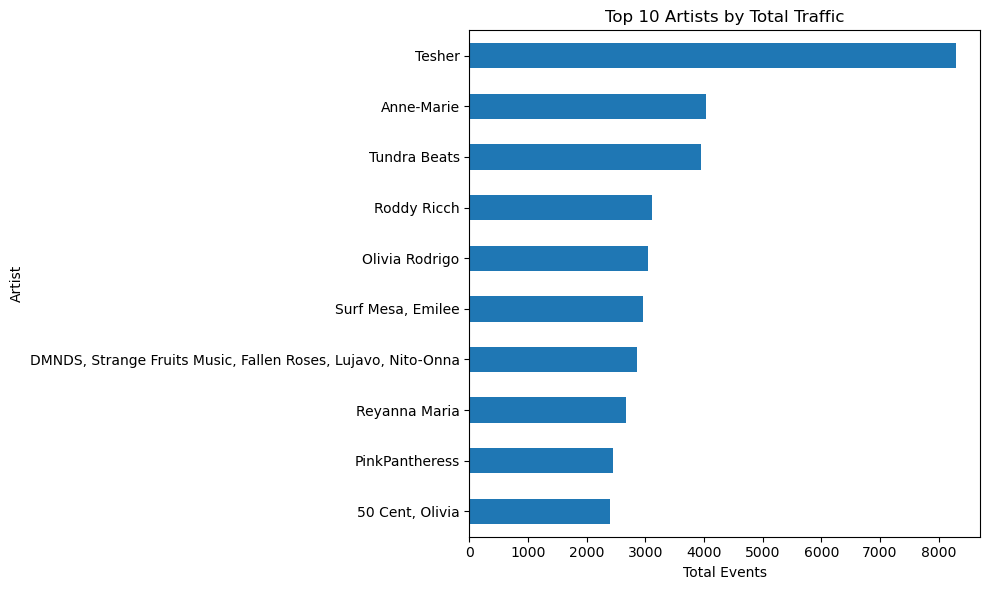

In [34]:
top_artists = artist_metrics.head(10)

top_artists['total_events'].sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Top 10 Artists by Total Traffic')
plt.xlabel('Total Events')
plt.ylabel('Artist')

plt.tight_layout()
plt.show()

In [35]:
artist_metrics['click_rate'] = (
    artist_metrics['click'] /
    artist_metrics['pageview'].replace(0, np.nan)
) * 100

In [36]:
artist_filtered = artist_metrics[
    artist_metrics['pageview'] >= 50
]

artist_filtered.sort_values(
    'click_rate',
    ascending=False
).head(10)

event,click,pageview,preview,total_events,click_rate
artist,,,,,
Sahir Ali Bagga,53,67,0,120,79.104478
Sueco,204,329,66,599,62.006079
"Simone & Simaria, Sebastian Yatra",46,77,26,149,59.740260
Kodak Black,192,329,36,557,58.358663
Soldier Kidd,214,367,59,640,58.310627
FINNEAS,51,88,26,165,57.954545
"Lil Tecca, Gunna",277,478,0,755,57.949791
Nessa Barrett,53,92,12,157,57.608696
"Vandelux, Alex Maher",49,86,25,160,56.976744


In [37]:
total_events = len(df)

pageviews = (df['event'] == 'pageview').sum()
previews = (df['event'] == 'preview').sum()
clicks = (df['event'] == 'click').sum()

pageview_click_rate = clicks / pageviews * 100
preview_pageview_rate = previews / pageviews * 100

kpi_summary = pd.DataFrame({
    'Metric': [
        'Total Events',
        'Pageviews',
        'Previews',
        'Clicks',
        'Pageview → Click Event Rate',
        'Pageview → Preview Event Rate',
        'Countries',
        'Cities',
        'Artists',
        'Tracks',
        'Unique Links'
    ],
    'Value': [
        total_events,
        pageviews,
        previews,
        clicks,
        round(pageview_click_rate, 2),
        round(preview_pageview_rate, 2),
        df['country'].nunique(),
        df['city'].nunique(),
        df['artist'].nunique(),
        df['track'].nunique(),
        df['linkid'].nunique()
    ]
})

kpi_summary

,Metric,Value
0,Total Events,122567.00
1,Pageviews,73360.00
2,Previews,16708.00
3,Clicks,32499.00
4,Pageview → Click Event Rate,44.30
5,Pageview → Preview Event Rate,22.78
6,Countries,211.00
7,Cities,11993.00
8,Artists,2419.00
9,Tracks,3562.00


In [38]:
kpi_summary.to_csv(
    'phase2_kpi_summary.csv',
    index=False
)

In [39]:
country_metrics.to_csv(
    'country_metrics.csv'
)

In [40]:
artist_metrics.to_csv(
    'artist_metrics.csv'
)

In [41]:
link_metrics.to_csv(
    'link_metrics.csv'
)